# Figure 5 revision (UHVDB r6 CF metagenomes)

Remake panels from `cf_activity_classifier.ipynb` and `cf_pathogen_pth.ipynb` using **UHVDB r6** CF profiling outputs:

1. **Richness vs sequencing depth** (species per sample), colored by airway
2. **ICTV class / host family / lifestyle** stacked proportions by airway
3. **CF pathogen PTH** by host genus
4. **All-virus PTH**: top 10 host genera by median PTH

**Data**
- CoverM: `cf_metag_r6/results/<sample>/<sample>.depth.tsv.gz`
- Sylph: `cf_metag_r6/results/<sample>/<sample>.profile.tsv`
- Metadata: `toolkit2/databases/uhvdb/v6/analyze/uhvdb_metadata.tsv.gz`
- GTDB taxonomy: `figure_4/sylph_tax/gtdb_r226_metadata.tsv.gz`
- Airway labels: `cf_activity_results/cf_sample_type_airway3.tsv`

**Detection rule:** CoverM `breadth_ratio > 0` on UHVDB species representatives.  
**PTH:** virus sylph taxonomic abundance / co-detected host abundance.
- CF pathogens: scoped hosts (*P. aeruginosa*, *S. aureus*, *H. influenzae*, *S. maltophilia*; all *Achromobacter* / *Burkholderia*), **species-matched PTH only**.
- All-virus top genera: species → genus singleton.
**No uninducible / activity-classifier filter.**

**Environment:** `lgonsa` micromamba  
Outputs → `cf_activity_results_r6/`


In [1]:
### packages + paths
from __future__ import annotations

import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

plt.rcParams.update({"font.size": 12})

FIG_5 = Path.cwd().resolve()
if FIG_5.name != "figure_5":
    cand = FIG_5 / "uhvdb-manuscript" / "figure_5"
    if cand.is_dir():
        FIG_5 = cand
    elif (FIG_5 / "figure_5").is_dir():
        FIG_5 = FIG_5 / "figure_5"

ROOT = FIG_5.parents[1]
FIG_S15 = FIG_5.parent / "figure_s15"
sys.path.insert(0, str(FIG_S15))

from _he6_analysis_core import load_depth  # noqa: E402

METADATA = ROOT / "toolkit2" / "databases" / "uhvdb" / "v6" / "analyze" / "uhvdb_metadata.tsv.gz"
R6_RUN = FIG_5 / "cf_metag_r6"
R6_RESULTS = R6_RUN / "results"
SAMPLES_TSV = R6_RUN / "refs" / "samples.tsv"
AIRWAY_LABELS = FIG_5 / "cf_activity_results" / "cf_sample_type_airway3.tsv"
READ_DEPTH = FIG_5 / "cf_metag_read_depth.txt.gz"

OUT_DIR = FIG_5 / "cf_activity_results_r6"
OUT_DIR.mkdir(parents=True, exist_ok=True)
COVERM_AGG = OUT_DIR / "cf_metag_r6_coverm_results.tsv.gz"

print("FIG_5:", FIG_5)
print("METADATA:", METADATA)
print("R6_RESULTS:", R6_RESULTS)
print("OUT_DIR:", OUT_DIR)


FIG_5: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5
METADATA: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit2/databases/uhvdb/v6/analyze/uhvdb_metadata.tsv.gz
R6_RESULTS: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_metag_r6/results
OUT_DIR: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results_r6


In [2]:
### UHVDB r6/v6 metadata (drop RNA/RT ICTV classes)
uhvdb_full = pl.read_csv(METADATA, separator="	")

# Same RNA/RT exclusion list as cf_activity_classifier.ipynb
RNA_ICTV_CLASSES = {
    "Pisoniviricetes",
    "Flasuviricetes",
    "Alsuviricetes",
    "Howeltoviricetes",
    "Stelpaviricetes",
    "Miaviricetes",
    "Amabiliviricetes",
    "Leviviricetes",
    "Magsaviricetes",
    "Tolucaviricetes",
    "Monjiviricetes",
    "Chrymotiviricetes",
    "Revtraviricetes",
}
_n_meta_before = uhvdb_full.height
uhvdb_full = uhvdb_full.filter(
    pl.col("ictv_class").is_null() | ~pl.col("ictv_class").is_in(list(RNA_ICTV_CLASSES))
)
print(
    f"Removed RNA/RT ICTV classes: {_n_meta_before:,} -> {uhvdb_full.height:,} "
    f"({_n_meta_before - uhvdb_full.height:,} genomes excluded)"
)

_id_ictv = (
    uhvdb_full.select(
        ["uhvdb_id", "seq_name", "seqhash_rep", "species_cluster_id", "ictv_class"]
    )
    .unique("uhvdb_id")
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
)

print(
    f"metadata genomes={uhvdb_full.height:,}  "
    f"id_map={_id_ictv.height:,}  "
    f"species_reps={uhvdb_full.filter(pl.col('seq_name') == pl.col('seqhash_rep')).height:,}"
)


Removed RNA/RT ICTV classes: 1,541,381 -> 1,481,969 (59,412 genomes excluded)
metadata genomes=1,481,969  id_map=1,098,773  species_reps=1,098,662


In [3]:
### Aggregate r6 CoverM depth → coverm_df
# Prefer cached aggregate; otherwise load per-sample *.depth.tsv.gz via load_depth.

def list_r6_samples() -> list[str]:
    lines = [ln for ln in SAMPLES_TSV.read_text().splitlines() if ln.strip()]
    return [ln.split("\t")[0] for ln in lines]


if COVERM_AGG.exists():
    coverm_df = pl.read_csv(COVERM_AGG, separator="	")
    print(f"Loaded cached CoverM aggregate: {COVERM_AGG.name} ({coverm_df.height:,} rows)")
else:
    samples = list_r6_samples()
    parts: list[pl.DataFrame] = []
    n_ok = n_empty = n_miss = 0
    for i, sid in enumerate(samples, 1):
        depth = R6_RESULTS / sid / f"{sid}.depth.tsv.gz"
        empty = R6_RESULTS / sid / "no_contained_viruses"
        if depth.is_file():
            parts.append(load_depth(depth, sid))
            n_ok += 1
        elif empty.exists():
            n_empty += 1
        else:
            n_miss += 1
        if i % 200 == 0 or i == len(samples):
            print(
                f"  {i}/{len(samples)} depth={n_ok} empty={n_empty} missing={n_miss}",
                flush=True,
            )
    if not parts:
        raise SystemExit("No r6 CoverM depth files found")
    coverm_df = pl.concat(parts, how="diagonal_relaxed")
    # Restrict to non-RNA UHVDB genomes
    _non_rna_ids = uhvdb_full.select("uhvdb_id").unique()
    coverm_df = coverm_df.join(
        _non_rna_ids, left_on="contig_id", right_on="uhvdb_id", how="inner"
    )
    coverm_df.write_csv(COVERM_AGG, separator="	", compression="gzip")
    print(
        f"Wrote {COVERM_AGG.name}: {coverm_df.height:,} rows across "
        f"{coverm_df['sample_id'].n_unique():,} samples "
        f"(depth={n_ok}, no_contained={n_empty}, missing={n_miss})"
    )

print(
    f"coverm_df: {coverm_df.height:,} rows, "
    f"{coverm_df['sample_id'].n_unique():,} samples, "
    f"breadth_ratio>0: {coverm_df.filter(pl.col('breadth_ratio') > 0).height:,}"
)


Loaded cached CoverM aggregate: cf_metag_r6_coverm_results.tsv.gz (71,571 rows)
coverm_df: 71,571 rows, 1,799 samples, breadth_ratio>0: 71,571


In [4]:
### Detection events (sample × species) + airway / depth annotations
# r6 CoverM is already on sylph-contained species reps; still require
# seq_name == seqhash_rep after joining metadata for consistency with the v5 notebook.

read_depth = (
    pl.read_csv(READ_DEPTH, separator="	", has_header=False)
    .rename({"column_1": "sample_id", "column_2": "read_depth"})
)

airway_labels = (
    pl.read_csv(AIRWAY_LABELS, separator="	")
    .select(["sample_id", "airway_category"])
    .unique("sample_id")
)

all_detections = (
    coverm_df.filter(pl.col("breadth_ratio") > 0)
    .join(_id_ictv, left_on="contig_id", right_on="uhvdb_id", how="left")
    .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .sort(
        ["sample_id", "species_cluster_id", "breadth_ratio"],
        descending=[False, False, True],
    )
    .unique(["sample_id", "species_cluster_id"], keep="first")
    .select(
        ["sample_id", "species_cluster_id", "ictv_class", "contig_id", "breadth_ratio"]
    )
)

print(
    f"all_detections={all_detections.height:,} events across "
    f"{all_detections['sample_id'].n_unique():,} samples "
    f"({all_detections['species_cluster_id'].n_unique():,} species)"
)
print(
    "Airway overlap:",
    all_detections.select("sample_id")
    .unique()
    .join(airway_labels, on="sample_id", how="left")
    .group_by("airway_category")
    .len()
    .sort("len", descending=True),
)


all_detections=70,390 events across 1,797 samples (18,148 species)
Airway overlap: shape: (4, 2)
┌─────────────────┬─────┐
│ airway_category ┆ len │
│ ---             ┆ --- │
│ str             ┆ u32 │
╞═════════════════╪═════╡
│ upper_airway    ┆ 892 │
│ lower_airway    ┆ 868 │
│ other           ┆ 36  │
│ null            ┆ 1   │
└─────────────────┴─────┘


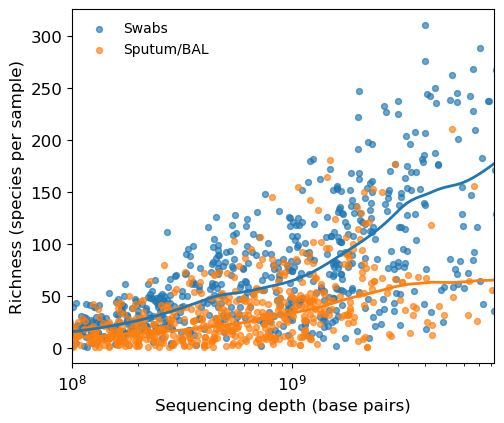

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results_r6/cf_activity_counts_by_read_depth.png
shape: (2, 4)
┌──────────────┬───────────┬──────────────┬────────────────┐
│ airway_label ┆ n_samples ┆ mean_species ┆ median_species │
│ ---          ┆ ---       ┆ ---          ┆ ---            │
│ str          ┆ u32       ┆ f64          ┆ f64            │
╞══════════════╪═══════════╪══════════════╪════════════════╡
│ Sputum/BAL   ┆ 160       ┆ 58.3         ┆ 46.5           │
│ Swabs        ┆ 272       ┆ 110.455882   ┆ 101.5          │
└──────────────┴───────────┴──────────────┴────────────────┘
Samples in plot by airway: shape: (2, 2)
┌──────────────┬───────────┐
│ airway_label ┆ n_samples │
│ ---          ┆ ---       │
│ str          ┆ u32       │
╞══════════════╪═══════════╡
│ Swabs        ┆ 892       │
│ Sputum/BAL   ┆ 868       │
└──────────────┴───────────┘


In [5]:
### Richness vs sequencing depth (by airway)
# Single panel (no uninducible filter). Same LOWESS + log-x style as the original.

airway_order_raw = ["upper_airway", "lower_airway"]
airway_display = {"upper_airway": "Swabs", "lower_airway": "Sputum/BAL"}
airway_palette = {"upper_airway": "#1f77b4", "lower_airway": "#ff7f0e"}

richness = (
    all_detections.join(read_depth, on="sample_id", how="left")
    .group_by(["sample_id", "read_depth"])
    .len()
    .filter(pl.col("read_depth").is_not_null())
    .join(airway_labels, on="sample_id", how="left")
    .filter(pl.col("airway_category").is_in(airway_order_raw))
    .with_columns(
        pl.col("airway_category").replace(airway_display).alias("airway_label")
    )
)

x_max = richness.select(pl.col("read_depth").quantile(0.99)).item()
pdf = richness.to_pandas()

fig, ax = plt.subplots(figsize=(5.2, 4.4))
for cat in airway_order_raw:
    sub = pdf[pdf["airway_category"] == cat]
    if sub.empty:
        continue
    sns.regplot(
        data=sub,
        x="read_depth",
        y="len",
        lowess=True,
        scatter_kws={"s": 18, "alpha": 0.65},
        line_kws={"linewidth": 2.0},
        color=airway_palette[cat],
        label=airway_display[cat],
        ax=ax,
    )

ax.set_xlim(1e8, x_max)
ax.set_xscale("log")
ax.set_xlabel("Sequencing depth (base pairs)")
ax.set_ylabel("Richness (species per sample)")
ax.legend(frameon=False, fontsize=10)
fig.tight_layout()

depth_png = OUT_DIR / "cf_activity_counts_by_read_depth.png"
fig.savefig(depth_png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", depth_png)

print(
    richness.filter(pl.col("read_depth") >= 1e9)
    .group_by("airway_label")
    .agg(
        [
            pl.len().alias("n_samples"),
            pl.col("len").mean().alias("mean_species"),
            pl.col("len").median().alias("median_species"),
        ]
    )
    .sort("airway_label")
)
print(
    "Samples in plot by airway:",
    richness.group_by("airway_label").agg(
        pl.col("sample_id").n_unique().alias("n_samples")
    ),
)


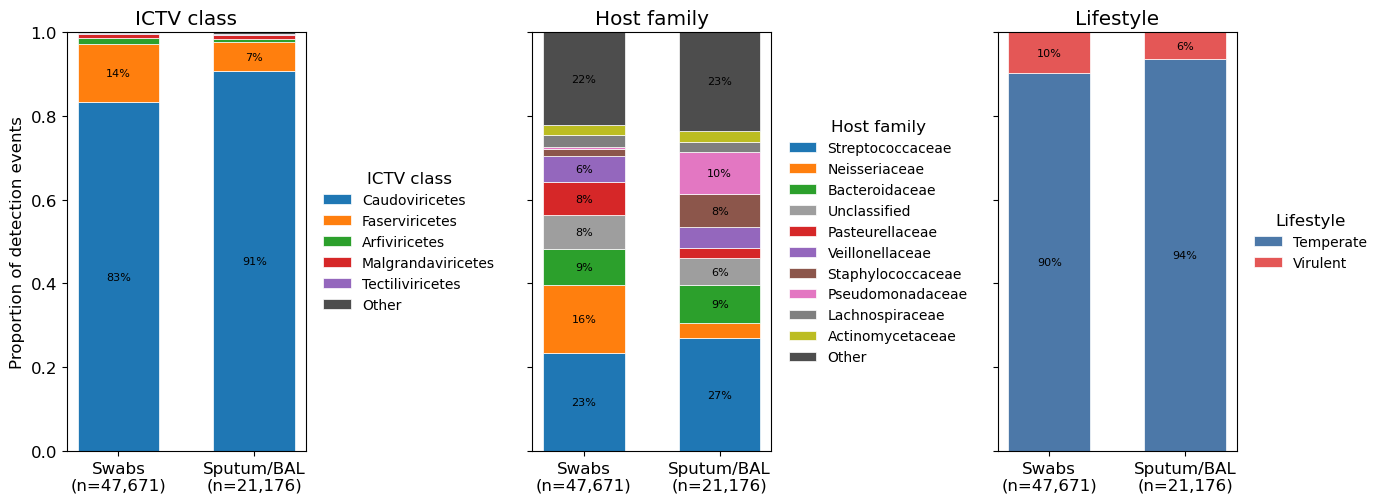

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results_r6/cf_activity_ictv_host_lifestyle.png
events with airway label: 68,847  (upper=47,671, lower=21,176)


rank,airway_label,taxon_plot,n,proportion
str,str,str,u32,f64
"""host_family""","""Sputum/BAL""","""Streptococcaceae""",5698,0.269078
"""host_family""","""Sputum/BAL""","""Other""",4968,0.234605
"""host_family""","""Sputum/BAL""","""Pseudomonadaceae""",2098,0.099074
"""host_family""","""Sputum/BAL""","""Bacteroidaceae""",1948,0.091991
"""host_family""","""Sputum/BAL""","""Staphylococcaceae""",1695,0.080043
…,…,…,…,…
"""ictv_class""","""Swabs""","""Other""",70,0.001468
"""lifestyle""","""Sputum/BAL""","""Temperate""",19803,0.935162
"""lifestyle""","""Sputum/BAL""","""Virulent""",1373,0.064838


In [6]:
### ICTV class, host family, and lifestyle (by airway)
# Detection events (sample × species), no uninducible filter.
# Panels (L→R): ICTV class (top 5 + Other), host family (top 10 + Other),
# lifestyle (temperate vs virulent).
# Temperate if >=1 signal: integrated provirus, BACPHLIP temperate (>0.5),
# or an integration-related gene (PHROG/Empathi).

sp_ictv = (
    uhvdb_full.filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .select(["species_cluster_id", "ictv_class", "ictv_family"])
    .unique("species_cluster_id")
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
)

sp_host_life = uhvdb_full.select(
    [
        "species_cluster_id",
        "seq_name",
        "seqhash_rep",
        "host_lineage",
        "temperate",
        "integration_status",
        "phrog_integration_excision",
        "empathi_integration",
    ]
).with_columns(pl.col("species_cluster_id").cast(pl.Int64))

sp_annot = (
    sp_host_life.group_by("species_cluster_id")
    .agg(
        [
            pl.col("host_lineage")
            .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
            .first()
            .alias("host_lineage"),
            (pl.col("integration_status") == "integrated").any().alias("has_integrated"),
            (pl.col("temperate") > 0.5).any().alias("has_bacphlip_temperate"),
            (
                (pl.col("phrog_integration_excision").fill_null(0) > 0)
                | (pl.col("empathi_integration").fill_null(0) > 0)
            )
            .any()
            .alias("has_integration_gene"),
        ]
    )
    .with_columns(
        [
            pl.col("host_lineage")
            .cast(pl.Utf8)
            .str.extract(r"f__([^;|]+)", 1)
            .fill_null("Unclassified")
            .alias("host_family"),
            pl.when(
                pl.col("has_integrated")
                | pl.col("has_bacphlip_temperate")
                | pl.col("has_integration_gene")
            )
            .then(pl.lit("Temperate"))
            .otherwise(pl.lit("Virulent"))
            .alias("lifestyle"),
        ]
    )
    .select(["species_cluster_id", "host_family", "lifestyle"])
)

sp_annot_plot = sp_annot.join(sp_ictv, on="species_cluster_id", how="left")

events = (
    all_detections.join(sp_annot_plot, on="species_cluster_id", how="left")
    .join(airway_labels, on="sample_id", how="left")
    .filter(pl.col("airway_category").is_in(["upper_airway", "lower_airway"]))
    .with_columns(
        pl.col("airway_category")
        .replace({"upper_airway": "Swabs", "lower_airway": "Sputum/BAL"})
        .alias("airway_label")
    )
)


def overall_top(df: pl.DataFrame, col: str, top_n: int) -> list[str]:
    return (
        df.with_columns(pl.col(col).fill_null("Unclassified").alias(col))
        .group_by(col)
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
        .head(top_n)[col]
        .to_list()
    )


def taxonomy_props_by_airway(
    df: pl.DataFrame, col: str, top: list[str]
) -> pd.DataFrame:
    """Collapse using an overall top list (+ Other); proportions within each airway."""
    labeled = df.with_columns(
        pl.when(pl.col(col).fill_null("Unclassified").is_in(top))
        .then(pl.col(col).fill_null("Unclassified"))
        .otherwise(pl.lit("Other"))
        .alias("taxon_plot")
    )
    return (
        labeled.group_by(["airway_label", "taxon_plot"])
        .agg(pl.len().alias("n"))
        .with_columns(
            (pl.col("n") / pl.col("n").sum().over("airway_label")).alias("proportion")
        )
        .to_pandas()
    )


airway_order = ["Swabs", "Sputum/BAL"]
lifestyle_order = ["Temperate", "Virulent"]
class_order = overall_top(events, "ictv_class", 5) + ["Other"]
host_order = overall_top(events, "host_family", 10) + ["Other"]

class_props = taxonomy_props_by_airway(events, "ictv_class", class_order[:-1])
host_props = taxonomy_props_by_airway(events, "host_family", host_order[:-1])
life_props = taxonomy_props_by_airway(events, "lifestyle", lifestyle_order)


def stacked_taxonomy_airway(ax, props_df, order, airway_order, title):
    wide = (
        props_df.pivot(index="airway_label", columns="taxon_plot", values="proportion")
        .reindex(index=airway_order, columns=order)
        .fillna(0.0)
    )
    counts = (
        props_df.pivot(index="airway_label", columns="taxon_plot", values="n")
        .reindex(index=airway_order, columns=order)
        .fillna(0)
        .astype(int)
    )
    named = [t for t in order if t not in ("Other", "Unclassified")]
    palette = sns.color_palette("tab10", n_colors=max(len(named), 1))
    color_map = {t: palette[i % len(palette)] for i, t in enumerate(named)}
    color_map["Other"] = "#4d4d4d"
    color_map["Unclassified"] = "#9e9e9e"
    color_map["Temperate"] = "#4C78A8"
    color_map["Virulent"] = "#E45756"

    bottom = np.zeros(len(airway_order))
    x = np.arange(len(airway_order))
    for taxon in order:
        vals = (
            wide[taxon].to_numpy()
            if taxon in wide.columns
            else np.zeros(len(airway_order))
        )
        ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.6,
            label=taxon,
            color=color_map.get(taxon, "#cccccc"),
            edgecolor="white",
            linewidth=0.5,
        )
        for i, v in enumerate(vals):
            if v >= 0.05:
                ax.text(
                    x[i],
                    bottom[i] + v / 2,
                    f"{v:.0%}",
                    ha="center",
                    va="center",
                    fontsize=8,
                )
        bottom = bottom + vals

    n_map = counts.sum(axis=1).to_dict()
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{s}\n(n={int(n_map.get(s, 0)):,})" for s in airway_order]
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("Proportion of detection events")
    ax.set_title(title)


fig, axes = plt.subplots(1, 3, figsize=(14, 5.2), sharey=True)
stacked_taxonomy_airway(axes[0], class_props, class_order, airway_order, "ICTV class")
stacked_taxonomy_airway(axes[1], host_props, host_order, airway_order, "Host family")
stacked_taxonomy_airway(axes[2], life_props, lifestyle_order, airway_order, "Lifestyle")
axes[1].set_ylabel("")
axes[2].set_ylabel("")

for ax, title in zip(axes, ["ICTV class", "Host family", "Lifestyle"]):
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles,
        labels,
        title=title,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=10,
    )

fig.tight_layout()

combo_png = OUT_DIR / "cf_activity_ictv_host_lifestyle.png"
fig.savefig(combo_png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", combo_png)
print(
    f"events with airway label: {events.height:,}  "
    f"(upper={events.filter(pl.col('airway_label') == 'Swabs').height:,}, "
    f"lower={events.filter(pl.col('airway_label') == 'Sputum/BAL').height:,})"
)

combo_summary = (
    pl.concat(
        [
            pl.from_pandas(class_props).with_columns(pl.lit("ictv_class").alias("rank")),
            pl.from_pandas(host_props).with_columns(pl.lit("host_family").alias("rank")),
            pl.from_pandas(life_props).with_columns(pl.lit("lifestyle").alias("rank")),
        ]
    )
    .select(["rank", "airway_label", "taxon_plot", "n", "proportion"])
    .sort(["rank", "airway_label", "n"], descending=[False, False, True])
)
combo_summary.write_csv(
    OUT_DIR / "cf_activity_ictv_host_lifestyle_summary.tsv", separator="	"
)
combo_summary


In [7]:
### Aggregate r6 sylph profiles (UHVDB viruses + GTDB bacteria)
# Cache under OUT_DIR; virus Contig_name = UHVDB-*; bacteria from Genome_file accession.

GTDB_META = (
    FIG_5.parent / "figure_4" / "sylph_tax" / "gtdb_r226_metadata.tsv.gz"
)
SYLPH_VIRUS_AGG = OUT_DIR / "cf_metag_r6_sylph_virus.tsv.gz"
SYLPH_BAC_AGG = OUT_DIR / "cf_metag_r6_sylph_bacteria.tsv.gz"

gtdb_tax = (
    pl.read_csv(GTDB_META, separator="	", has_header=False, new_columns=["accession", "taxonomy"])
    .with_columns(
        [
            pl.col("taxonomy").str.extract(r"g__([^|;]+)", 1).alias("bac_genus_raw"),
            pl.col("taxonomy").str.extract(r"s__([^|;]+)", 1).alias("bac_species"),
        ]
    )
    .with_columns(
        pl.col("bac_genus_raw").str.replace(r"_([A-Z])$", "").alias("bac_genus")
    )
    .filter(pl.col("bac_genus").is_not_null())
    .unique("accession")
)
print(f"GTDB r226 accessions with genus: {gtdb_tax.height:,}")


def list_r6_samples() -> list[str]:
    lines = [ln for ln in SAMPLES_TSV.read_text().splitlines() if ln.strip()]
    return [ln.split("	")[0] for ln in lines]


if SYLPH_VIRUS_AGG.exists() and SYLPH_BAC_AGG.exists():
    sylph_virus = pl.read_csv(SYLPH_VIRUS_AGG, separator="	")
    sylph_bac = pl.read_csv(SYLPH_BAC_AGG, separator="	")
    print(
        f"Loaded cached sylph: virus={sylph_virus.height:,}  bac={sylph_bac.height:,}"
    )
else:
    samples = list_r6_samples()
    virus_parts: list[pl.DataFrame] = []
    bac_parts: list[pl.DataFrame] = []
    n_ok = n_miss = 0
    for i, sid in enumerate(samples, 1):
        path = R6_RESULTS / sid / f"{sid}.profile.tsv"
        if not path.is_file():
            n_miss += 1
            continue
        df = pl.read_csv(path, separator="	")
        n_ok += 1
        virus_parts.append(
            df.filter(pl.col("Contig_name").str.starts_with("UHVDB-"))
            .select(
                [
                    pl.lit(sid).alias("sample_id"),
                    pl.col("Contig_name").alias("uhvdb_id"),
                    pl.col("Taxonomic_abundance")
                    .cast(pl.Float64)
                    .alias("virus_abund"),
                ]
            )
        )
        bac_parts.append(
            df.filter(~pl.col("Contig_name").str.starts_with("UHVDB-"))
            .with_columns(
                [
                    pl.lit(sid).alias("sample_id"),
                    pl.col("Genome_file")
                    .cast(pl.Utf8)
                    .str.extract(r"(GC[AF]_\d+\.\d+)", 1)
                    .alias("accession"),
                    pl.col("Taxonomic_abundance")
                    .cast(pl.Float64)
                    .alias("bac_taxonomic_abundance"),
                ]
            )
            .filter(pl.col("accession").is_not_null())
            .select(
                ["sample_id", "accession", "bac_taxonomic_abundance"]
            )
        )
        if i % 200 == 0 or i == len(samples):
            print(
                f"  {i}/{len(samples)} profiles={n_ok} missing={n_miss}",
                flush=True,
            )
    sylph_virus = pl.concat(virus_parts, how="vertical_relaxed")
    sylph_bac_raw = pl.concat(bac_parts, how="vertical_relaxed")
    sylph_bac = (
        sylph_bac_raw.join(gtdb_tax, on="accession", how="left")
        .filter(pl.col("bac_genus").is_not_null())
        .group_by(["sample_id", "bac_species", "bac_genus", "bac_genus_raw"])
        .agg(pl.col("bac_taxonomic_abundance").sum())
    )
    sylph_virus.write_csv(SYLPH_VIRUS_AGG, separator="	", compression="gzip")
    sylph_bac.write_csv(SYLPH_BAC_AGG, separator="	", compression="gzip")
    print(
        f"Wrote sylph caches: virus={sylph_virus.height:,}  "
        f"bac={sylph_bac.height:,}  samples_virus={sylph_virus['sample_id'].n_unique():,}"
    )


GTDB r226 accessions with genus: 732,475
Loaded cached sylph: virus=72,353  bac=65,313


In [8]:
### PTH tables from r6 CoverM ∩ sylph (no uninducible filter)
# CF pathogens: scoped hosts + species-matched PTH only.
# All-virus: species → genus singleton.
# Virus host from v6 host_lineage on species reps; bacterial denom from GTDB r226.

# CF pathogen host scope:
# - species-restricted: P. aeruginosa, S. aureus, H. influenzae, S. maltophilia
# - genus-wide: Achromobacter, Burkholderia
CF_GENERA = [
    "Pseudomonas",
    "Staphylococcus",
    "Haemophilus",
    "Achromobacter",
    "Stenotrophomonas",
    "Burkholderia",
]
CF_SPECIES_RESTRICTED = {
    "Pseudomonas": r"Pseudomonas(?:_[A-Z])? aeruginosa",
    "Staphylococcus": r"Staphylococcus(?:_[A-Z])? aureus",
    "Haemophilus": r"Haemophilus(?:_[A-Z])? influenzae",
    "Stenotrophomonas": r"Stenotrophomonas(?:_[A-Z])? maltophilia",
}
CF_GENUS_WIDE = {"Achromobacter", "Burkholderia"}
CF_HOST_COLORS = dict(
    zip(
        sorted(CF_GENERA),
        sns.color_palette("tab10", n_colors=len(CF_GENERA)),
    )
)
MIN_VIRUS_SPECIES = 10
TOP_N_HOST_GENERA = 10


def is_cf_pathogen_host(species_col: str, genus_col: str) -> pl.Expr:
    """True if host is in the CF pathogen species/genus scope."""
    expr = pl.lit(False)
    for genus in CF_GENUS_WIDE:
        expr = expr | (pl.col(genus_col) == genus)
    for genus, spe_re in CF_SPECIES_RESTRICTED.items():
        expr = expr | (
            (pl.col(genus_col) == genus)
            & pl.col(species_col).cast(pl.Utf8).str.contains(spe_re)
        )
    return expr


sp_meta = (
    uhvdb_full.filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .select(
        [
            "species_cluster_id",
            "genus_cluster_id",
            "family_cluster_id",
            "ictv_class",
            "ictv_family",
            "ictv_genus",
            "ictv_species",
            "host_lineage",
        ]
    )
    .unique("species_cluster_id")
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
)

# CoverM detections (reuse all_detections if present)
coverm_det = (
    all_detections.select(
        ["sample_id", "species_cluster_id", "contig_id", "ictv_class", "breadth_ratio"]
    )
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
)
coverm_samples = coverm_det["sample_id"].unique().to_list()
print(
    f"CoverM detections: {coverm_det.height:,}  samples={len(coverm_samples):,}"
)

# Map UHVDB profile hits → species + host annotation
id_to_sp = (
    uhvdb_full.select(["uhvdb_id", "species_cluster_id"])
    .unique("uhvdb_id")
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
)

virus_sylph = (
    sylph_virus.filter(pl.col("sample_id").is_in(coverm_samples))
    .join(id_to_sp, on="uhvdb_id", how="inner")
    .group_by(["sample_id", "species_cluster_id"])
    .agg(pl.col("virus_abund").max())
    .join(sp_meta, on="species_cluster_id", how="left")
    .with_columns(
        [
            pl.col("host_lineage")
            .cast(pl.Utf8)
            .str.replace_all(";", "|")
            .alias("virus_host"),
        ]
    )
    .with_columns(
        [
            pl.col("virus_host").str.extract(r"g__([^|;]+)", 1).alias("host_genus_raw"),
            pl.col("virus_host")
            .str.extract(r"s__([^|;]+)", 1)
            .alias("host_species"),
            pl.col("virus_host").str.contains("s__").fill_null(False).alias("has_species_host"),
            pl.col("virus_host").str.contains("g__").fill_null(False).alias("has_genus_host"),
        ]
    )
    .with_columns(
        pl.col("host_genus_raw").str.replace(r"_([A-Z])$", "").alias("host_genus")
    )
    .filter(pl.col("virus_host").is_not_null())
)

bac_in_sample_all = (
    sylph_bac.filter(pl.col("sample_id").is_in(coverm_samples))
    .filter(pl.col("bac_species").is_not_null())
    .select(
        [
            "sample_id",
            "bac_species",
            "bac_genus",
            "bac_genus_raw",
            "bac_taxonomic_abundance",
        ]
    )
)

bac_in_sample = bac_in_sample_all.filter(
    is_cf_pathogen_host("bac_species", "bac_genus")
)

virus_cf = virus_sylph.filter(
    is_cf_pathogen_host("host_species", "host_genus")
    | (
        # genus-wide hosts may be predicted only to genus (no s__)
        pl.col("host_genus").is_in(list(CF_GENUS_WIDE))
        & pl.col("has_genus_host")
    )
)

virus_det = (
    coverm_det.select(["sample_id", "species_cluster_id", "breadth_ratio"])
    .join(
        virus_cf.select(
            [
                "sample_id",
                "species_cluster_id",
                "virus_host",
                "virus_abund",
                "host_genus_raw",
                "host_genus",
                "host_species",
                "has_species_host",
                "has_genus_host",
            ]
        ),
        on=["sample_id", "species_cluster_id"],
        how="inner",
    )
    .join(
        sp_meta.select(
            [
                "species_cluster_id",
                "genus_cluster_id",
                "family_cluster_id",
                "ictv_class",
                "ictv_family",
                "ictv_genus",
                "ictv_species",
            ]
        ),
        on="species_cluster_id",
        how="left",
    )
)
print(
    f"CF-pathogen virus detections (CoverM ∩ sylph): {virus_det.height:,}  "
    f"samples={virus_det['sample_id'].n_unique():,}  "
    f"species={virus_det['species_cluster_id'].n_unique():,}"
)
print(virus_det.group_by("host_genus").len().sort("len", descending=True))


def hierarchical_pth(
    virus_det_df: pl.DataFrame,
    bac_df: pl.DataFrame,
    *,
    allow_genus_singleton: bool = True,
) -> pl.DataFrame:
    """Species-host match, optionally else genus singleton. PTH = virus_abund / host_abundance."""
    rule1 = (
        virus_det_df.filter(pl.col("has_species_host") & pl.col("host_species").is_not_null())
        .join(
            bac_df.select(
                [
                    "sample_id",
                    pl.col("bac_species").alias("host_species"),
                    pl.col("bac_taxonomic_abundance").alias("host_abundance"),
                    pl.col("bac_species").alias("vhr_host"),
                ]
            ),
            on=["sample_id", "host_species"],
            how="inner",
        )
        .with_columns(pl.lit("species").alias("match_method"))
    )
    keys = ["sample_id", "species_cluster_id"]
    if not allow_genus_singleton:
        return (
            virus_det_df.join(
                rule1.select(keys + ["vhr_host", "host_abundance", "match_method"]),
                on=keys,
                how="left",
            )
            .filter(pl.col("host_abundance").is_not_null() & (pl.col("host_abundance") > 0))
            .with_columns((pl.col("virus_abund") / pl.col("host_abundance")).alias("pth"))
        )

    genus_members = (
        bac_df.group_by(["sample_id", "bac_genus"])
        .agg(
            [
                pl.len().alias("n_species_in_genus"),
                pl.col("bac_species")
                .sort_by("bac_taxonomic_abundance", descending=True)
                .first()
                .alias("top_species"),
                pl.col("bac_taxonomic_abundance").max().alias("top_abundance"),
            ]
        )
        .rename({"bac_genus": "host_genus"})
    )
    rule2 = (
        virus_det_df.filter(pl.col("has_genus_host") & pl.col("host_genus").is_not_null())
        .join(
            genus_members.filter(pl.col("n_species_in_genus") == 1),
            on=["sample_id", "host_genus"],
            how="inner",
        )
        .with_columns(
            [
                pl.col("top_species").alias("vhr_host"),
                pl.col("top_abundance").alias("host_abundance"),
                pl.lit("genus_singleton").alias("match_method"),
            ]
        )
    )
    return (
        virus_det_df.join(
            rule1.select(keys + ["vhr_host", "host_abundance", "match_method"]),
            on=keys,
            how="left",
        )
        .join(
            rule2.select(
                keys
                + [
                    pl.col("vhr_host").alias("vhr_host_r2"),
                    pl.col("host_abundance").alias("host_abundance_r2"),
                    pl.col("match_method").alias("match_method_r2"),
                ]
            ),
            on=keys,
            how="left",
        )
        .with_columns(
            [
                pl.when(pl.col("vhr_host").is_not_null())
                .then(pl.col("vhr_host"))
                .otherwise(pl.col("vhr_host_r2"))
                .alias("vhr_host"),
                pl.when(pl.col("host_abundance").is_not_null())
                .then(pl.col("host_abundance"))
                .otherwise(pl.col("host_abundance_r2"))
                .alias("host_abundance"),
                pl.when(pl.col("match_method").is_not_null())
                .then(pl.col("match_method"))
                .otherwise(pl.col("match_method_r2"))
                .alias("match_method"),
            ]
        )
        .filter(pl.col("host_abundance").is_not_null() & (pl.col("host_abundance") > 0))
        .with_columns((pl.col("virus_abund") / pl.col("host_abundance")).alias("pth"))
        .drop(["vhr_host_r2", "host_abundance_r2", "match_method_r2"])
    )


# CF pathogens: require predicted host species == bacterial species (no genus fallback).
pth_df = hierarchical_pth(
    virus_det, bac_in_sample, allow_genus_singleton=False
).with_columns(pl.col("host_genus").alias("pathogen"))
print("=== CF-pathogen species-matched PTH (scoped hosts) ===")
print(f"detections={virus_det.height:,}  with PTH={pth_df.height:,}")
print(
    pth_df.group_by("match_method")
    .len()
    .with_columns((pl.col("len") / pth_df.height).alias("frac"))
    .sort("match_method")
)
print(
    pth_df.group_by("pathogen")
    .agg(
        [
            pl.len().alias("n_detections"),
            pl.col("sample_id").n_unique().alias("n_samples"),
            pl.col("species_cluster_id").n_unique().alias("n_species"),
            pl.col("host_species").n_unique().alias("n_host_species"),
            pl.col("pth").median().alias("median_pth"),
        ]
    )
    .sort("n_detections", descending=True)
)
print("Staph host species:")
print(
    pth_df.filter(pl.col("pathogen") == "Staphylococcus")
    .group_by("host_species")
    .len()
    .sort("len", descending=True)
)

# All-virus detections (CoverM ∩ sylph with any host)
virus_det_all = (
    coverm_det.select(["sample_id", "species_cluster_id", "breadth_ratio"])
    .join(
        virus_sylph.select(
            [
                "sample_id",
                "species_cluster_id",
                "virus_host",
                "virus_abund",
                "host_genus_raw",
                "host_genus",
                "host_species",
                "has_species_host",
                "has_genus_host",
            ]
        ),
        on=["sample_id", "species_cluster_id"],
        how="inner",
    )
    .join(
        sp_meta.select(
            [
                "species_cluster_id",
                "genus_cluster_id",
                "family_cluster_id",
                "ictv_class",
                "ictv_family",
                "ictv_genus",
                "ictv_species",
            ]
        ),
        on="species_cluster_id",
        how="left",
    )
)
pth_df_all = hierarchical_pth(virus_det_all, bac_in_sample_all)
print("=== All-virus hierarchical PTH ===")
print(f"CoverM ∩ sylph w/ predicted host: {virus_det_all.height:,}")
print(f"with PTH (species → genus singleton): {pth_df_all.height:,}")
print(f"Overall median PTH: {float(pth_df_all['pth'].median()):.4f}")
print(
    pth_df_all.group_by("match_method")
    .len()
    .with_columns((pl.col("len") / pth_df_all.height).alias("frac"))
    .sort("match_method")
)

# Fraction of ALL CoverM species-rep detections with a usable PTH
n_coverm = coverm_det.height
n_pth = pth_df_all.height
print("=== PTH coverage among all CoverM species-rep detections ===")
print(f"CoverM species-rep detections: {n_coverm:,}")
print(
    f"with PTH prediction (species host co-detected, else genus singleton): "
    f"{n_pth:,} / {n_coverm:,} ({n_pth / max(n_coverm, 1):.1%})"
)
print(
    "By match_method (fractions of CoverM detections):",
    pth_df_all.group_by("match_method")
    .len()
    .with_columns((pl.col("len") / n_coverm).alias("frac_of_coverm"))
    .sort("match_method"),
)


CoverM detections: 70,390  samples=1,797
CF-pathogen virus detections (CoverM ∩ sylph): 4,569  samples=881  species=600
shape: (6, 2)
┌──────────────────┬──────┐
│ host_genus       ┆ len  │
│ ---              ┆ ---  │
│ str              ┆ u32  │
╞══════════════════╪══════╡
│ Pseudomonas      ┆ 2283 │
│ Staphylococcus   ┆ 1857 │
│ Stenotrophomonas ┆ 135  │
│ Burkholderia     ┆ 130  │
│ Haemophilus      ┆ 104  │
│ Achromobacter    ┆ 60   │
└──────────────────┴──────┘
=== CF-pathogen species-matched PTH (scoped hosts) ===
detections=4,569  with PTH=4,454
shape: (1, 3)
┌──────────────┬──────┬──────┐
│ match_method ┆ len  ┆ frac │
│ ---          ┆ ---  ┆ ---  │
│ str          ┆ u32  ┆ f64  │
╞══════════════╪══════╪══════╡
│ species      ┆ 4454 ┆ 1.0  │
└──────────────┴──────┴──────┘
shape: (6, 6)
┌──────────────────┬──────────────┬───────────┬───────────┬────────────────┬────────────┐
│ pathogen         ┆ n_detections ┆ n_samples ┆ n_species ┆ n_host_species ┆ median_pth │
│ ---            

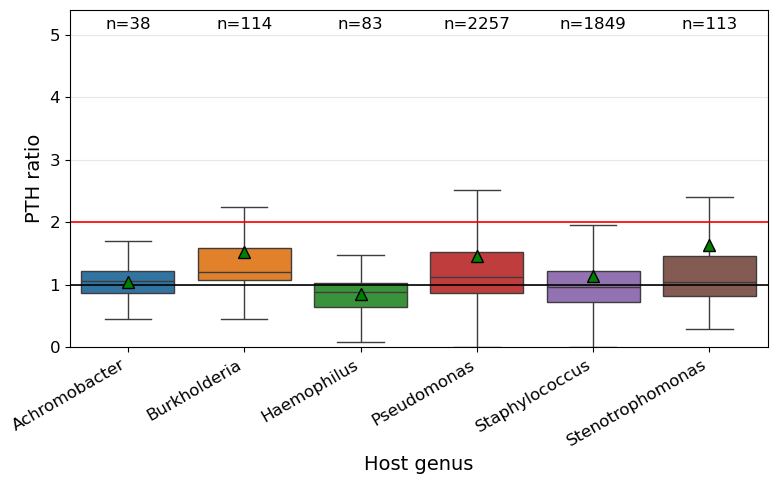

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results_r6/cf_pathogen_pth_by_genus.png
Overall median PTH: 1.0482252966056056
Counts by pathogen: {'Haemophilus': 83, 'Pseudomonas': 2257, 'Staphylococcus': 1849, 'Stenotrophomonas': 113, 'Burkholderia': 114, 'Achromobacter': 38}
Detections with PTH ≥ 2: 468 / 4,454 (10.5%)


In [9]:
### Plot: PTH by CF pathogen genus (r6; scoped species/genera; species-matched host)
plot_df = pth_df.filter(pl.col("pth").is_not_null() & (pl.col("pth") > 0))

genus_order = sorted(plot_df["pathogen"].drop_nulls().unique().to_list())
genus_count = (
    plot_df.group_by("pathogen").len().to_pandas().set_index("pathogen")["len"].to_dict()
)
genus_palette = {g: CF_HOST_COLORS[g] for g in genus_order if g in CF_HOST_COLORS}

pdf = plot_df.select(["pathogen", "pth", "match_method"]).to_pandas()
pdf = pdf[np.isfinite(pdf["pth"]) & (pdf["pth"] > 0)]

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=pdf,
    x="pathogen",
    y="pth",
    order=genus_order,
    hue="pathogen",
    hue_order=genus_order,
    palette=genus_palette,
    dodge=False,
    legend=False,
    showfliers=False,
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "black",
        "markersize": 8,
    },
    ax=ax,
)
ax.set_xticks(range(len(genus_order)))
ax.set_xticklabels(genus_order, rotation=30, ha="right")
ax.set_xlabel("Host genus", fontsize=14)
ax.set_ylabel("PTH ratio", fontsize=14)
ax.set_ylim(0, 5.4)
ax.axhline(1, color="black", linewidth=1.2)
ax.axhline(2, color="red", linewidth=1.2)
for i, genus in enumerate(genus_order):
    ax.text(
        i,
        5.05,
        f"n={genus_count.get(genus, 0)}",
        ha="center",
        va="bottom",
        fontsize=12,
    )
ax.tick_params(axis="x", rotation=30)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
png = OUT_DIR / "cf_pathogen_pth_by_genus.png"
fig.savefig(png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", png)
print("Overall median PTH:", float(plot_df["pth"].median()))
print("Counts by pathogen:", genus_count)
n_pth_ge2 = plot_df.filter(pl.col("pth") >= 2.0).height
print(
    f"Detections with PTH ≥ 2: {n_pth_ge2:,} / {plot_df.height:,} "
    f"({n_pth_ge2 / max(plot_df.height, 1):.1%})"
)


=== All-virus hierarchical PTH (species → genus singleton) ===
Detections with PTH: 26,150
Overall median PTH: 0.9627

By match_method:
shape: (2, 3)
┌─────────────────┬───────┬──────────┐
│ match_method    ┆ len   ┆ frac     │
│ ---             ┆ ---   ┆ ---      │
│ str             ┆ u32   ┆ f64      │
╞═════════════════╪═══════╪══════════╡
│ genus_singleton ┆ 4291  ┆ 0.164092 │
│ species         ┆ 21859 ┆ 0.835908 │
└─────────────────┴───────┴──────────┘

Host genera with ≥10 virus species: 68
shape: (25, 6)
┌─────────────────┬──────────────┬───────────┬─────────────────┬────────────┬───────────┐
│ host_genus      ┆ n_detections ┆ n_samples ┆ n_virus_species ┆ median_pth ┆ mean_pth  │
│ ---             ┆ ---          ┆ ---       ┆ ---             ┆ ---        ┆ ---       │
│ str             ┆ u32          ┆ u32       ┆ u32             ┆ f64        ┆ f64       │
╞═════════════════╪══════════════╪═══════════╪═════════════════╪════════════╪═══════════╡
│ Arachnia        ┆ 63           

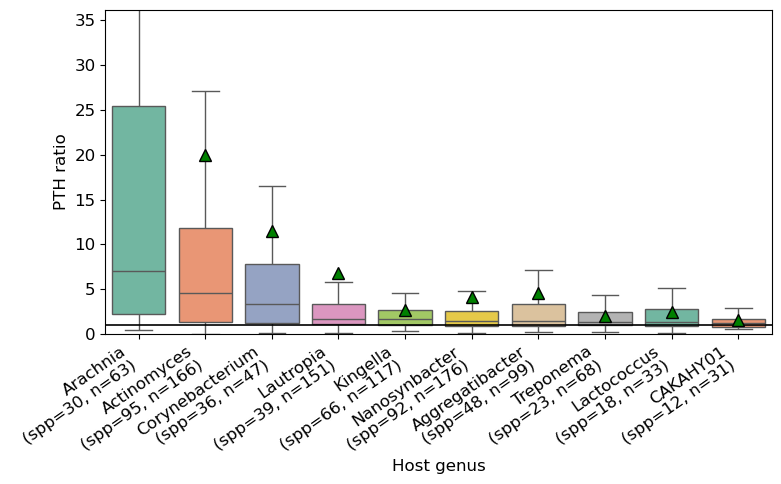

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results_r6/all_virus_pth_top10_host_genera.png
Wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results_r6/all_virus_pth_by_host_genus.tsv.gz
Overall median PTH (all viruses): 0.962653594168932


In [10]:
### All-virus PTH: top host genera by median PTH (r6; no uninducible filter)
plot_df_all = pth_df_all.filter(pl.col("pth").is_not_null() & (pl.col("pth") > 0))
overall_median_pth = float(plot_df_all["pth"].median())
print("=== All-virus hierarchical PTH (species → genus singleton) ===")
print(f"Detections with PTH: {plot_df_all.height:,}")
print(f"Overall median PTH: {overall_median_pth:.4f}")
print("\nBy match_method:")
print(
    plot_df_all.group_by("match_method")
    .len()
    .with_columns((pl.col("len") / plot_df_all.height).alias("frac"))
    .sort("match_method")
)

host_genus_summary = (
    plot_df_all.group_by("host_genus")
    .agg(
        [
            pl.len().alias("n_detections"),
            pl.col("sample_id").n_unique().alias("n_samples"),
            pl.col("species_cluster_id").n_unique().alias("n_virus_species"),
            pl.col("pth").median().alias("median_pth"),
            pl.col("pth").mean().alias("mean_pth"),
        ]
    )
    .filter(pl.col("n_virus_species") >= MIN_VIRUS_SPECIES)
    .sort("median_pth", descending=True)
)
print(
    f"\nHost genera with ≥{MIN_VIRUS_SPECIES} virus species: "
    f"{host_genus_summary.height:,}"
)
print(host_genus_summary.head(25))

top_genera = host_genus_summary.head(TOP_N_HOST_GENERA)
genus_order = top_genera["host_genus"].to_list()
genus_meta = {r["host_genus"]: r for r in top_genera.iter_rows(named=True)}
print(f"\nTop {TOP_N_HOST_GENERA} host genera by median PTH:")
print(top_genera)

pdf_all = (
    plot_df_all.filter(pl.col("host_genus").is_in(genus_order))
    .select(["host_genus", "pth"])
    .to_pandas()
)
pdf_all = pdf_all[np.isfinite(pdf_all["pth"]) & (pdf_all["pth"] > 0)]

genus_palette = dict(
    zip(genus_order, sns.color_palette("Set2", n_colors=len(genus_order)))
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=pdf_all,
    x="host_genus",
    y="pth",
    order=genus_order,
    hue="host_genus",
    hue_order=genus_order,
    palette=genus_palette,
    dodge=False,
    legend=False,
    showfliers=False,
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "black",
        "markersize": 8,
    },
    ax=ax,
)
ax.set_xticks(range(len(genus_order)))
ax.set_xticklabels(
    [
        f"{g}\n(spp={genus_meta[g]['n_virus_species']}, "
        f"n={genus_meta[g]['n_detections']})"
        for g in genus_order
    ],
    rotation=35,
    ha="right",
)
ax.set_xlabel("Host genus")
ax.set_ylabel("PTH ratio")
ax.set_ylim(0, max(5, float(np.nanpercentile(pdf_all["pth"], 95)) * 1.1))
ax.axhline(1, color="black", linewidth=1.2, label="y=1")
fig.tight_layout()
png = OUT_DIR / "all_virus_pth_top10_host_genera.png"
fig.savefig(png, dpi=150, bbox_inches="tight")
plt.show()

out = OUT_DIR / "all_virus_pth_by_host_genus.tsv.gz"
host_genus_summary.write_csv(out, separator="	", compression="gzip")
print("Saved", png)
print("Wrote", out)
print("Overall median PTH (all viruses):", overall_median_pth)


=== PTH by topology ===
shape: (4, 4)
┌────────────┬──────────────┬───────────┬────────────┐
│ TOPOLOGY   ┆ n_detections ┆ n_species ┆ median_pth │
│ ---        ┆ ---          ┆ ---       ┆ ---        │
│ str        ┆ u32          ┆ u32       ┆ f64        │
╞════════════╪══════════════╪═══════════╪════════════╡
│ Integrated ┆ 10172        ┆ 2989      ┆ 0.947288   │
│ DTR        ┆ 2390         ┆ 1158      ┆ 1.029826   │
│ ITR        ┆ 49           ┆ 25        ┆ 1.152457   │
│ Unknown    ┆ 13539        ┆ 3862      ┆ 0.965052   │
└────────────┴──────────────┴───────────┴────────────┘

=== PTH by confident lifestyle (uncertain dropped) ===
shape: (2, 4)
┌─────────────────────┬──────────────┬───────────┬────────────┐
│ confident_lifestyle ┆ n_detections ┆ n_species ┆ median_pth │
│ ---                 ┆ ---          ┆ ---       ┆ ---        │
│ str                 ┆ u32          ┆ u32       ┆ f64        │
╞═════════════════════╪══════════════╪═══════════╪════════════╡
│ Confident temperate 

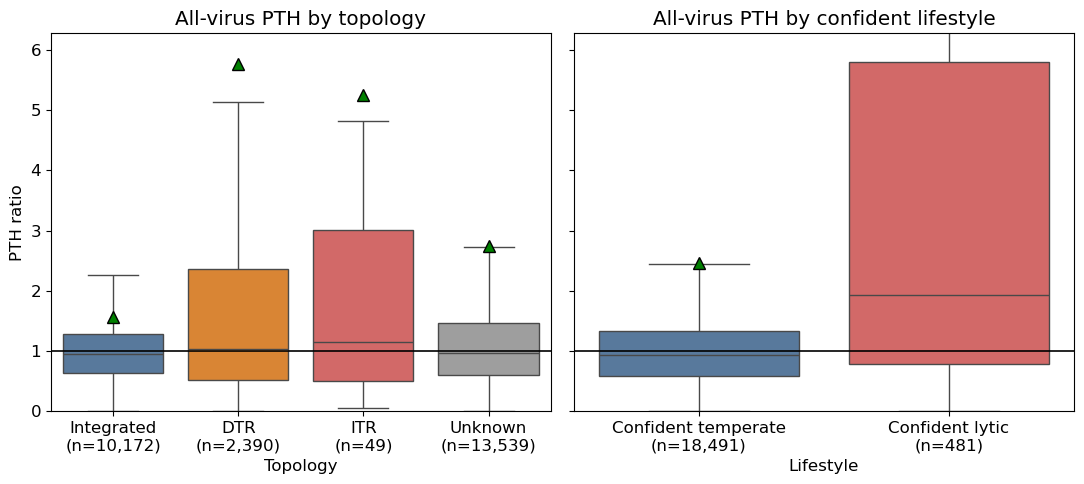

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results_r6/all_virus_pth_by_topology_lifestyle.png

=== Confident lytic host genus distribution ===
detections=481  genera=52
shape: (15, 4)
┌─────────────────────┬──────────────┬───────────┬───────────┐
│ host_genus          ┆ n_detections ┆ n_species ┆ n_samples │
│ ---                 ┆ ---          ┆ ---       ┆ ---       │
│ str                 ┆ u32          ┆ u32       ┆ u32       │
╞═════════════════════╪══════════════╪═══════════╪═══════════╡
│ Actinomyces         ┆ 60           ┆ 37        ┆ 56        │
│ Prevotella          ┆ 55           ┆ 27        ┆ 53        │
│ Rothia              ┆ 46           ┆ 28        ┆ 45        │
│ Streptococcus       ┆ 29           ┆ 20        ┆ 20        │
│ Neisseria           ┆ 21           ┆ 14        ┆ 21        │
│ …                   ┆ …            ┆ …         ┆ …         │
│ Pauljensenia        ┆ 16           ┆ 13        ┆ 13    

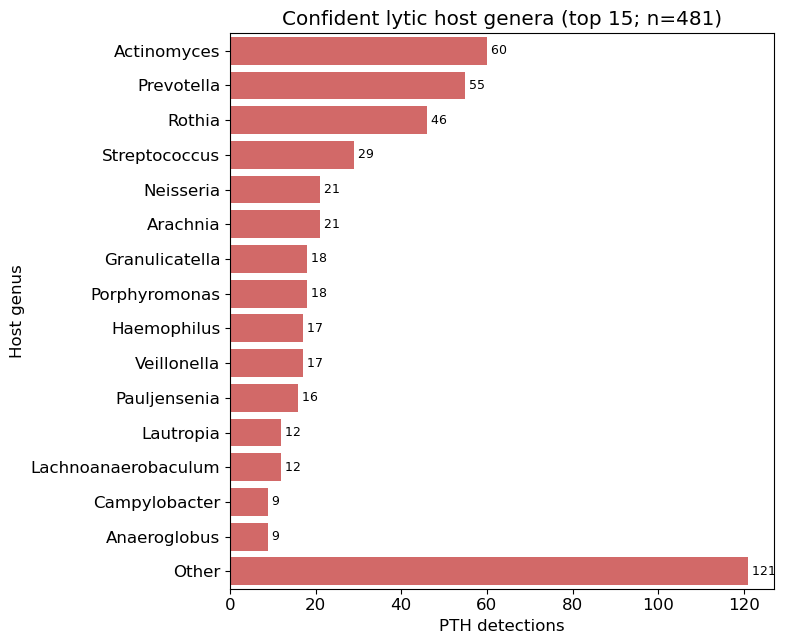

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results_r6/all_virus_pth_confident_lytic_host_genera.png


In [19]:
### All-virus PTH by topology and confident lifestyle
# Topology (species-rep metadata; same rules as analysis.ipynb):
#   Integrated / DTR / ITR / Unknown
# Confident temperate: integrated OR (integrase ≥1 AND virulent < 0.5)
# Confident lytic: DTR/ITR + virulent > 0.5 + no integrase / integration-excision / Empathi
# Uncertain lifestyles dropped from lifestyle panel.

sp_topo_life = (
    uhvdb_full.filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .select(
        [
            "species_cluster_id",
            "integration_status",
            "topology",
            "completeness_method",
            "phrog_integrases",
            "phrog_integration_excision",
            "empathi_integration",
            "virulent",
        ]
    )
    .unique("species_cluster_id")
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
    .with_columns(
        [
            pl.col("phrog_integrases").fill_null(0),
            pl.col("phrog_integration_excision").fill_null(0),
            pl.col("empathi_integration").fill_null(0),
            pl.when(pl.col("integration_status") == "integrated")
            .then(pl.lit("Integrated"))
            .when(
                pl.col("topology").str.contains("DTR")
                | pl.col("completeness_method").str.contains("DTR")
            )
            .then(pl.lit("DTR"))
            .when(
                pl.col("topology").str.contains("ITR")
                | pl.col("completeness_method").str.contains("ITR")
            )
            .then(pl.lit("ITR"))
            .otherwise(pl.lit("Unknown"))
            .alias("TOPOLOGY"),
        ]
    )
    .with_columns(
        pl.when(
            (pl.col("integration_status") == "integrated")
            | ((pl.col("phrog_integrases") >= 1) & (pl.col("virulent") < 0.5))
        )
        .then(pl.lit("Confident temperate"))
        .when(
            pl.col("TOPOLOGY").is_in(["DTR", "ITR"])
            & (pl.col("virulent") > 0.5)
            & (pl.col("phrog_integrases") == 0)
            # & (pl.col("phrog_integration_excision") == 0)
            # & (pl.col("empathi_integration") == 0)
        )
        .then(pl.lit("Confident lytic"))
        .otherwise(pl.lit("Uncertain"))
        .alias("confident_lifestyle"),
    )
    # .select(["species_cluster_id", "TOPOLOGY", "confident_lifestyle"])
)

pth_annot = (
    pth_df_all.filter(pl.col("pth").is_not_null() & (pl.col("pth") > 0))
    .join(sp_topo_life, on="species_cluster_id", how="left")
)

topo_order = ["Integrated", "DTR", "ITR", "Unknown"]
life_order = ["Confident temperate", "Confident lytic"]
topo_palette = {
    "Integrated": "#4C78A8",
    "DTR": "#F58518",
    "ITR": "#E45756",
    "Unknown": "#9e9e9e",
}
life_palette = {
    "Confident temperate": "#4C78A8",
    "Confident lytic": "#E45756",
}

print("=== PTH by topology ===")
print(
    pth_annot.group_by("TOPOLOGY")
    .agg(
        [
            pl.len().alias("n_detections"),
            pl.col("species_cluster_id").n_unique().alias("n_species"),
            pl.col("pth").median().alias("median_pth"),
        ]
    )
    .sort(pl.col("TOPOLOGY").cast(pl.Enum(topo_order)))
)
print("\n=== PTH by confident lifestyle (uncertain dropped) ===")
print(
    pth_annot.filter(pl.col("confident_lifestyle").is_in(life_order))
    .group_by("confident_lifestyle")
    .agg(
        [
            pl.len().alias("n_detections"),
            pl.col("species_cluster_id").n_unique().alias("n_species"),
            pl.col("pth").median().alias("median_pth"),
        ]
    )
    .sort(pl.col("confident_lifestyle").cast(pl.Enum(life_order)))
)
n_uncertain = pth_annot.filter(pl.col("confident_lifestyle") == "Uncertain").height
print(
    f"Dropped uncertain: {n_uncertain:,} / {pth_annot.height:,} "
    f"({n_uncertain / max(pth_annot.height, 1):.1%})"
)

pdf_topo = (
    pth_annot.filter(pl.col("TOPOLOGY").is_in(topo_order))
    .select(["TOPOLOGY", "pth"])
    .to_pandas()
)
pdf_topo = pdf_topo[np.isfinite(pdf_topo["pth"]) & (pdf_topo["pth"] > 0)]

pdf_life = (
    pth_annot.filter(pl.col("confident_lifestyle").is_in(life_order))
    .select(["confident_lifestyle", "pth"])
    .to_pandas()
)
pdf_life = pdf_life[np.isfinite(pdf_life["pth"]) & (pdf_life["pth"] > 0)]

y_max = max(
    5,
    float(np.nanpercentile(pdf_topo["pth"], 95)) * 1.1,
    float(np.nanpercentile(pdf_life["pth"], 95)) * 1.1 if len(pdf_life) else 5,
)
meanprops = {
    "marker": "^",
    "markerfacecolor": "green",
    "markeredgecolor": "black",
    "markersize": 8,
}

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

sns.boxplot(
    data=pdf_topo,
    x="TOPOLOGY",
    y="pth",
    order=topo_order,
    hue="TOPOLOGY",
    hue_order=topo_order,
    palette=topo_palette,
    dodge=False,
    legend=False,
    showfliers=False,
    showmeans=True,
    meanprops=meanprops,
    ax=axes[0],
)
topo_counts = pdf_topo["TOPOLOGY"].value_counts()
axes[0].set_xticks(range(len(topo_order)))
axes[0].set_xticklabels(
    [f"{t}\n(n={int(topo_counts.get(t, 0)):,})" for t in topo_order]
)
axes[0].set_xlabel("Topology")
axes[0].set_ylabel("PTH ratio")
axes[0].set_ylim(0, y_max)
axes[0].axhline(1, color="black", linewidth=1.2)
axes[0].set_title("All-virus PTH by topology")

sns.boxplot(
    data=pdf_life,
    x="confident_lifestyle",
    y="pth",
    order=life_order,
    hue="confident_lifestyle",
    hue_order=life_order,
    palette=life_palette,
    dodge=False,
    legend=False,
    showfliers=False,
    showmeans=True,
    meanprops=meanprops,
    ax=axes[1],
)
life_counts = pdf_life["confident_lifestyle"].value_counts()
axes[1].set_xticks(range(len(life_order)))
axes[1].set_xticklabels(
    [f"{t}\n(n={int(life_counts.get(t, 0)):,})" for t in life_order]
)
axes[1].set_xlabel("Lifestyle")
axes[1].set_ylabel("")
axes[1].axhline(1, color="black", linewidth=1.2)
axes[1].set_title("All-virus PTH by confident lifestyle")

fig.tight_layout()
png = OUT_DIR / "all_virus_pth_by_topology_lifestyle.png"
fig.savefig(png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", png)

# Host genus distribution among confident lytic detections with PTH
TOP_N_LYTIC_HOST = 15
lytic_host = pth_annot.filter(
    (pl.col("confident_lifestyle") == "Confident lytic")
    & pl.col("host_genus").is_not_null()
)
lytic_genus_counts = (
    lytic_host.group_by("host_genus")
    .agg(
        [
            pl.len().alias("n_detections"),
            pl.col("species_cluster_id").n_unique().alias("n_species"),
            pl.col("sample_id").n_unique().alias("n_samples"),
        ]
    )
    .sort("n_detections", descending=True)
)
print("\n=== Confident lytic host genus distribution ===")
print(f"detections={lytic_host.height:,}  genera={lytic_genus_counts.height:,}")
print(lytic_genus_counts.head(TOP_N_LYTIC_HOST))

top_lytic_genera = lytic_genus_counts.head(TOP_N_LYTIC_HOST)["host_genus"].to_list()
lytic_plot = (
    lytic_host.with_columns(
        pl.when(pl.col("host_genus").is_in(top_lytic_genera))
        .then(pl.col("host_genus"))
        .otherwise(pl.lit("Other"))
        .alias("host_genus_plot")
    )
    .group_by("host_genus_plot")
    .agg(pl.len().alias("n_detections"))
    .to_pandas()
)
genus_order_lytic = top_lytic_genera + (["Other"] if (lytic_plot["host_genus_plot"] == "Other").any() else [])
lytic_plot["host_genus_plot"] = pd.Categorical(
    lytic_plot["host_genus_plot"], categories=genus_order_lytic, ordered=True
)
lytic_plot = lytic_plot.sort_values("host_genus_plot")

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(genus_order_lytic) + 1)))
sns.barplot(
    data=lytic_plot,
    y="host_genus_plot",
    x="n_detections",
    order=genus_order_lytic,
    color=life_palette["Confident lytic"],
    ax=ax,
)
for i, row in enumerate(lytic_plot.itertuples(index=False)):
    ax.text(
        row.n_detections,
        i,
        f" {int(row.n_detections):,}",
        va="center",
        fontsize=9,
    )
ax.set_xlabel("PTH detections")
ax.set_ylabel("Host genus")
ax.set_title(
    f"Confident lytic host genera (top {TOP_N_LYTIC_HOST}; n={lytic_host.height:,})"
)
fig.tight_layout()
png_lytic = OUT_DIR / "all_virus_pth_confident_lytic_host_genera.png"
fig.savefig(png_lytic, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", png_lytic)


=== Confident lytic CoverM detections ===
detections=3,045  species=1,162  samples=1,096
with host genus: 2,033 / 3,045 (66.8%)
shape: (15, 4)
┌──────────────────┬──────────────┬───────────┬───────────┐
│ host_genus       ┆ n_detections ┆ n_species ┆ n_samples │
│ ---              ┆ ---          ┆ ---       ┆ ---       │
│ str              ┆ u32          ┆ u32       ┆ u32       │
╞══════════════════╪══════════════╪═══════════╪═══════════╡
│ No host assigned ┆ 1012         ┆ 253       ┆ 641       │
│ Streptococcus    ┆ 601          ┆ 278       ┆ 418       │
│ Haemophilus      ┆ 169          ┆ 83        ┆ 141       │
│ Prevotella       ┆ 163          ┆ 52        ┆ 148       │
│ Neisseria        ┆ 154          ┆ 47        ┆ 129       │
│ …                ┆ …            ┆ …         ┆ …         │
│ Arachnia         ┆ 45           ┆ 19        ┆ 45        │
│ Nanosynbacter    ┆ 30           ┆ 10        ┆ 28        │
│ Gemella          ┆ 26           ┆ 4         ┆ 25        │
│ Lautropia      

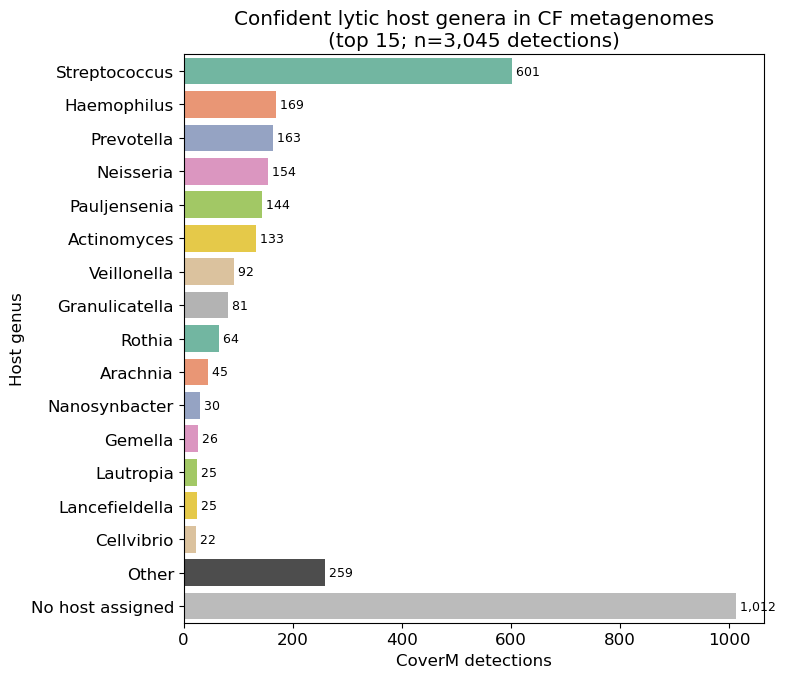

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5/cf_activity_results_r6/cf_metag_confident_lytic_host_genera.png


In [20]:
### Host genus distribution: confident lytic CoverM detections (CF metagenomes)
# Uses all_detections (breadth_ratio > 0), not PTH-restricted.
# Lifestyle rules match the topology/lifestyle cell above.

TOP_N_DET_HOST = 15

sp_lytic_host = (
    uhvdb_full.filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .select(
        [
            "species_cluster_id",
            "integration_status",
            "topology",
            "completeness_method",
            "phrog_integrases",
            "virulent",
            "host_lineage",
        ]
    )
    .unique("species_cluster_id")
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
    .with_columns(
        [
            pl.col("phrog_integrases").fill_null(0),
            pl.when(pl.col("integration_status") == "integrated")
            .then(pl.lit("Integrated"))
            .when(
                pl.col("topology").str.contains("DTR")
                | pl.col("completeness_method").str.contains("DTR")
            )
            .then(pl.lit("DTR"))
            .when(
                pl.col("topology").str.contains("ITR")
                | pl.col("completeness_method").str.contains("ITR")
            )
            .then(pl.lit("ITR"))
            .otherwise(pl.lit("Unknown"))
            .alias("TOPOLOGY"),
            pl.col("host_lineage")
            .cast(pl.Utf8)
            .str.replace_all(";", "|")
            .str.extract(r"g__([^|;]+)", 1)
            .str.replace(r"_([A-Z])$", "")
            .alias("host_genus"),
        ]
    )
    .with_columns(
        pl.when(
            (pl.col("integration_status") == "integrated")
            | ((pl.col("phrog_integrases") >= 1) & (pl.col("virulent") < 0.5))
        )
        .then(pl.lit("Confident temperate"))
        .when(
            pl.col("TOPOLOGY").is_in(["DTR", "ITR"])
            & (pl.col("virulent") > 0.5)
            & (pl.col("phrog_integrases") == 0)
        )
        .then(pl.lit("Confident lytic"))
        .otherwise(pl.lit("Uncertain"))
        .alias("confident_lifestyle"),
    )
    .select(["species_cluster_id", "confident_lifestyle", "host_genus"])
)

lytic_det = (
    all_detections.join(sp_lytic_host, on="species_cluster_id", how="left")
    .filter(pl.col("confident_lifestyle") == "Confident lytic")
)

n_lytic = lytic_det.height
n_with_genus = lytic_det.filter(pl.col("host_genus").is_not_null()).height
print("=== Confident lytic CoverM detections ===")
print(
    f"detections={n_lytic:,}  species={lytic_det['species_cluster_id'].n_unique():,}  "
    f"samples={lytic_det['sample_id'].n_unique():,}"
)
print(
    f"with host genus: {n_with_genus:,} / {n_lytic:,} "
    f"({n_with_genus / max(n_lytic, 1):.1%})"
)

lytic_genus_counts = (
    lytic_det.with_columns(
        pl.col("host_genus").fill_null("No host assigned").alias("host_genus")
    )
    .group_by("host_genus")
    .agg(
        [
            pl.len().alias("n_detections"),
            pl.col("species_cluster_id").n_unique().alias("n_species"),
            pl.col("sample_id").n_unique().alias("n_samples"),
        ]
    )
    .sort("n_detections", descending=True)
)
print(lytic_genus_counts.head(TOP_N_DET_HOST))

# Rank named genera only; keep "No host assigned" as its own bar if present
named = lytic_genus_counts.filter(pl.col("host_genus") != "No host assigned")
top_genera = named.head(TOP_N_DET_HOST)["host_genus"].to_list()
plot_df = (
    lytic_det.with_columns(
        pl.when(pl.col("host_genus").is_null())
        .then(pl.lit("No host assigned"))
        .when(pl.col("host_genus").is_in(top_genera))
        .then(pl.col("host_genus"))
        .otherwise(pl.lit("Other"))
        .alias("host_genus_plot")
    )
    .group_by("host_genus_plot")
    .agg(pl.len().alias("n_detections"))
    .to_pandas()
)
genus_order = top_genera[:]
if (plot_df["host_genus_plot"] == "Other").any():
    genus_order.append("Other")
if (plot_df["host_genus_plot"] == "No host assigned").any():
    genus_order.append("No host assigned")

plot_df["host_genus_plot"] = pd.Categorical(
    plot_df["host_genus_plot"], categories=genus_order, ordered=True
)
plot_df = plot_df.sort_values("host_genus_plot")

palette = {
    g: sns.color_palette("Set2", n_colors=max(len(top_genera), 1))[i % max(len(top_genera), 1)]
    for i, g in enumerate(top_genera)
}
palette["Other"] = "#4d4d4d"
palette["No host assigned"] = "#bbbbbb"

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(genus_order) + 1)))
sns.barplot(
    data=plot_df,
    y="host_genus_plot",
    x="n_detections",
    order=genus_order,
    hue="host_genus_plot",
    hue_order=genus_order,
    palette=palette,
    dodge=False,
    legend=False,
    ax=ax,
)
for i, row in enumerate(plot_df.itertuples(index=False)):
    ax.text(row.n_detections, i, f" {int(row.n_detections):,}", va="center", fontsize=9)
ax.set_xlabel("CoverM detections")
ax.set_ylabel("Host genus")
ax.set_title(
    f"Confident lytic host genera in CF metagenomes\n"
    f"(top {TOP_N_DET_HOST}; n={n_lytic:,} detections)"
)
fig.tight_layout()
png = OUT_DIR / "cf_metag_confident_lytic_host_genera.png"
fig.savefig(png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", png)
